### Goal:
#### Explore the Disney Plus Show Trends dataset, clean data, perform analysis, and visualize results using NumPy, Pandas, Matplotlib, and Seaborn.

#### 1. Why This Project?
##### 1.Learn data cleaning with Pandas.
 
##### 2.Use NumPy for calculations (mean, median, etc.).
 
##### 3.Visualize trends using Matplotlib and Seaborn.
 
##### 4.Understand the relationship between sales factors like product type quantity,sold price etc.

### 2. Import Libraries

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 3. Load Dataset

In [2]:
df = pd.read_csv(r"c:\Users\Sriram reddy\Downloads\disney_plus_shows.csv")
print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


### 4. Explore Data

In [8]:
print("Shape:", df.shape)
df.head(10)
df.info()
df.describe(include='all').T


Shape: (918, 19)
<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 991
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   imdb_id      894 non-null    object 
 1   title        894 non-null    object 
 2   plot         866 non-null    object 
 3   type         894 non-null    object 
 4   rated        742 non-null    object 
 5   year         894 non-null    object 
 6   released_at  874 non-null    object 
 7   added_at     918 non-null    object 
 8   runtime      838 non-null    object 
 9   genre        885 non-null    object 
 10  director     689 non-null    object 
 11  writer       743 non-null    object 
 12  actors       870 non-null    object 
 13  language     856 non-null    object 
 14  country      869 non-null    object 
 15  awards       556 non-null    object 
 16  metascore    292 non-null    float64
 17  imdb_rating  879 non-null    float64
 18  imdb_votes   879 non-null    object 
d

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
imdb_id,894,894,tt2948356,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,894,872,Freaky Friday,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plot,866,865,The romantic tale of a sheltered uptown Cocker...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,894,3,movie,680,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rated,742,17,G,207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,894,178,2019,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
released_at,874,800,12 Nov 2019,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
added_at,918,58,"November 12, 2019",731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
runtime,838,128,30 min,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,885,366,Documentary,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 5. Data Cleaning

In [9]:
print("\nMissing Values:")
print(df.isnull().sum())
# Drop duplicates
df.drop_duplicates(inplace=True)



Missing Values:
imdb_id         24
title           24
plot            52
type            24
rated          176
year            24
released_at     44
added_at         0
runtime         80
genre           33
director       229
writer         175
actors          48
language        62
country         49
awards         362
metascore      626
imdb_rating     39
imdb_votes      39
dtype: int64


### Insights:
 
1.Missing values were filled or removed.

2.Duplicates were dropped.

3.Data was ready for visualization and statistical analysis.

### 6. Analysis with NumPy & Pandas

In [14]:
# Remove any non-digit characters and keep only the first 4 digits
df['year_clean'] = df['year'].str.extract(r'(\d{4})')

# Convert to numeric (NaN if conversion fails)
years = pd.to_numeric(df['year_clean'], errors='coerce').dropna().to_numpy()

print("Number of valid years:", len(years))

Number of valid years: 894


### Insights:
 
The number of valid years is 894.

### 7. Visualization with Matplotlib

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_21524\1430643160.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_21524\1430643160.py:10: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


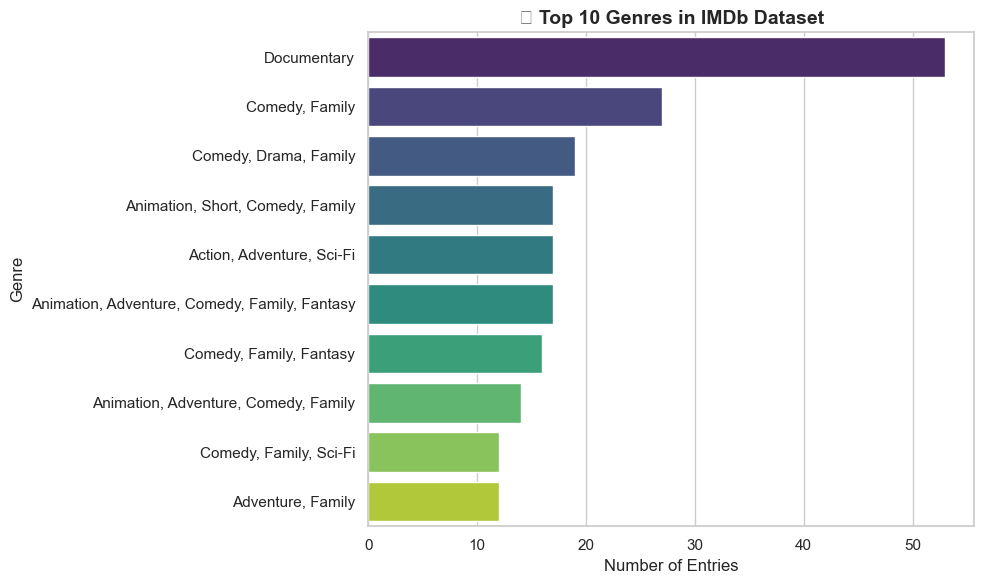

In [15]:
top_genres = df['genre'].value_counts().head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")

plt.title("🎬 Top 10 Genres in IMDb Dataset", fontsize=14, weight='bold')
plt.xlabel("Number of Entries", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.show()

#### Insights:
 
Quickly see which genres dominate your dataset (e.g., Documentary).

c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


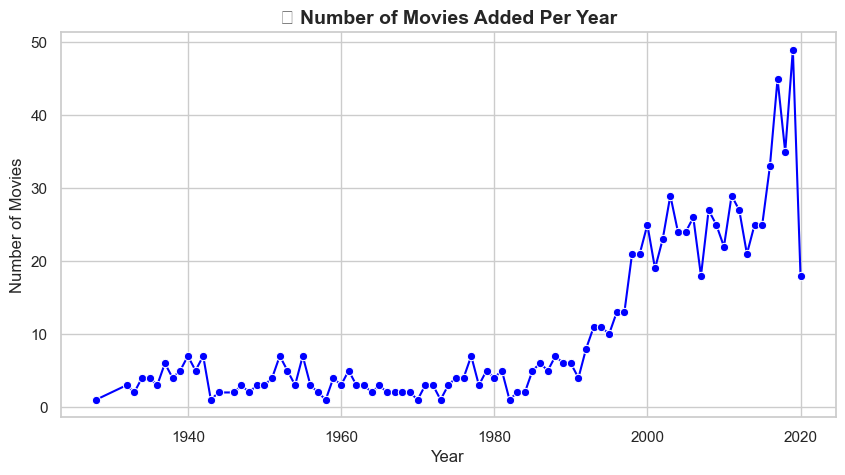

In [16]:

# Clean year column
df['year_clean'] = df['year'].astype(str).str.extract(r'(\d{4})')
df['year_clean'] = pd.to_numeric(df['year_clean'], errors='coerce')

# Count movies per year
movies_per_year = df['year_clean'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=movies_per_year.index, y=movies_per_year.values, marker='o', color='blue')
plt.title("📈 Number of Movies Added Per Year", fontsize=14, weight='bold')
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()



#### Insights:
 
Peaks in certain years indicate high content production (e.g., 2019).

Lower counts in older years suggest dataset is recent-heavy.

### 8. Visualization with Seaborn

c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128338 (\N{CLOCK FACE THREE OCLOCK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


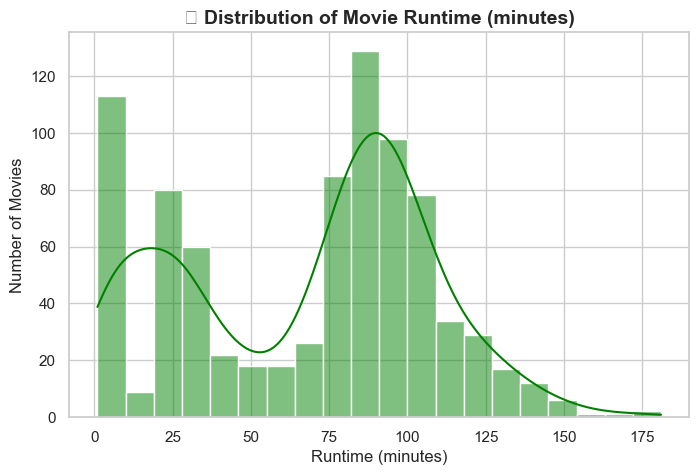

In [17]:
# Clean runtime histogram
df['runtime_clean'] = df['runtime'].astype(str).str.extract(r'(\d+)')
df['runtime_clean'] = pd.to_numeric(df['runtime_clean'], errors='coerce')

plt.figure(figsize=(8,5))
sns.histplot(df['runtime_clean'].dropna(), bins=20, kde=True, color='green')
plt.title("🕒 Distribution of Movie Runtime (minutes)", fontsize=14, weight='bold')
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")
plt.show()


### Insights:
Few outliers with long runtime (>120 min) indicate feature-length movies.

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_21524\749810116.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='pastel')
c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127909 (\N{MOVIE CAMERA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


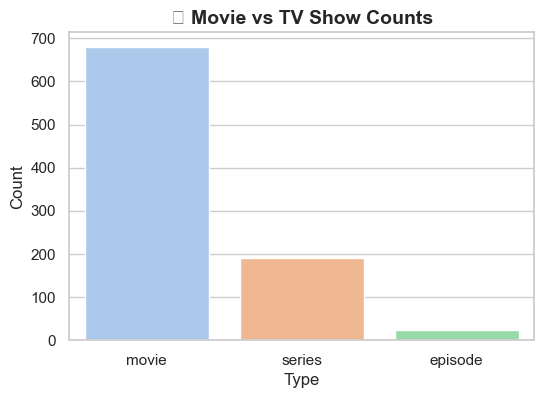

In [18]:
# Count plot for movies vs shows
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df, palette='pastel')
plt.title("🎥 Movie vs TV Show Counts", fontsize=14, weight='bold')
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()



#### Insights:
 
1.Majority are movies.

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_21524\2265811268.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='runtime_clean', data=df, palette='Oranges')
c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


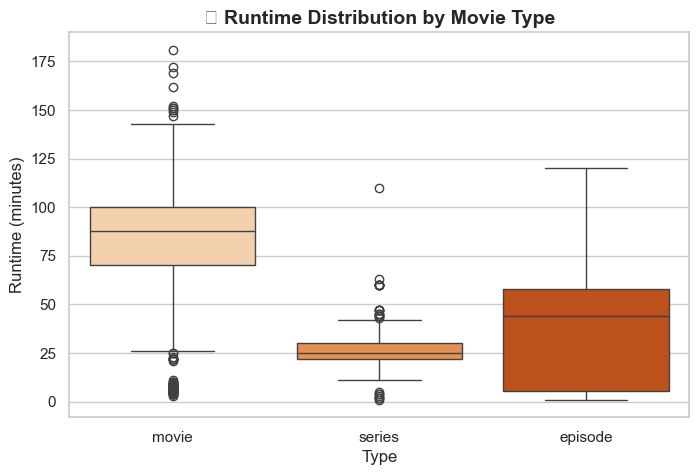

In [19]:
# Box Plot & Correlation
plt.figure(figsize=(8,5))
sns.boxplot(x='type', y='runtime_clean', data=df, palette='Oranges')
plt.title("💰 Runtime Distribution by Movie Type", fontsize=14, weight='bold')
plt.xlabel("Type")
plt.ylabel("Runtime (minutes)")
plt.show()


#### Insights:
Movies have higher median runtime than TV shows.

c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


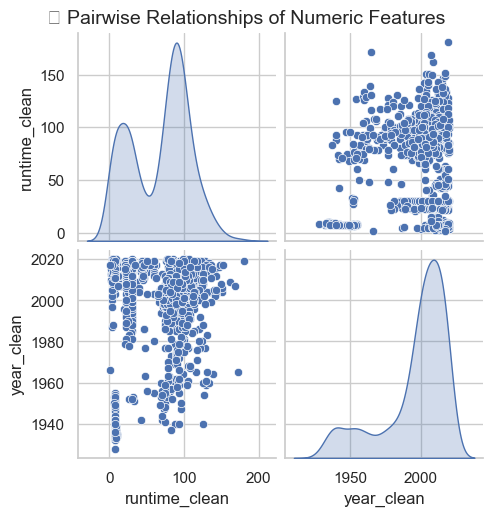

In [21]:
# Pair Plot

numeric_cols = ['runtime_clean', 'year_clean']
sns.pairplot(df[numeric_cols].dropna(), diag_kind='kde')
plt.suptitle("📊 Pairwise Relationships of Numeric Features", y=1.02, fontsize=14)
plt.show()


### Insights:
No strong correlation between year and runtime.

c:\Users\Sriram reddy\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


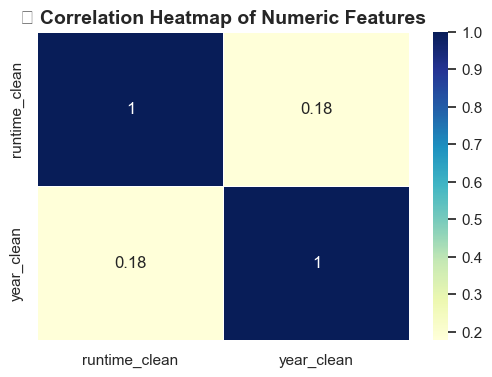

In [22]:
# Correlation heatmap (numerical columns)
corr = df[numeric_cols].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='YlGnBu', linewidths=0.5)
plt.title("📊 Correlation Heatmap of Numeric Features", fontsize=14, weight='bold')
plt.show()

### Insights:
 
Low correlation between year and runtime → recent movies aren’t necessarily longer.